In [87]:
## import dependencies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import plotly
import requests
import anndata 
import scanpy as sc
import nibabel as nib
from scipy.ndimage import rotate

# make plots bigger
plt.rcParams["figure.figsize"] = (12,10)

In [88]:
from STalign import STalign

## Define all slices

In [40]:
# load two slices
slice1 = sc.read_h5ad("/app/work/Processed_2p0slices.h5ad")

/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [41]:
# extract spatial coordinates
X1 = np.array(slice1.obs.x[slice1.obs.sample_id == 'T1089_MT66_P0_Visual_Sub-CTX_b100_filtered']).astype(float)
Y1 = np.array(slice1.obs.y[slice1.obs.sample_id == 'T1089_MT66_P0_Visual_Sub-CTX_b100_filtered']).astype(float)
X2 = np.array(slice1.obs.x[slice1.obs.sample_id == 'T1090_MT65_P0_Visual_Sub-CTX_b100_filtered']).astype(float)
Y2 = np.array(slice1.obs.y[slice1.obs.sample_id == 'T1090_MT65_P0_Visual_Sub-CTX_b100_filtered']).astype(float)

In [89]:
# transform spatial coordinates to appropriate format
# Rasterize Image
dx = 50
blur = 1
X_1,Y_1,W1 = STalign.rasterize(X1,Y1,dx=dx, blur = blur,draw=False)
X_2,Y_2,W2 = STalign.rasterize(X2,Y2,dx=dx, blur = blur,draw=False)

In [43]:
X1.shape

(19864,)

In [27]:
#! pip install nibabel

In [44]:
# Load the anatomical image
img = nib.load('/app/work/T1WI_444.nii')
imagefile = img.get_fdata()  #3D image volume 

# Load the label file
lab = nib.load('/app/work/Label111_444.nii')
labelfile= lab.get_fdata()  #3D annotation volume

In [90]:
W_new = W1[0, :, :]
W_new.shape

(407, 416)

## Prepare for the alignment

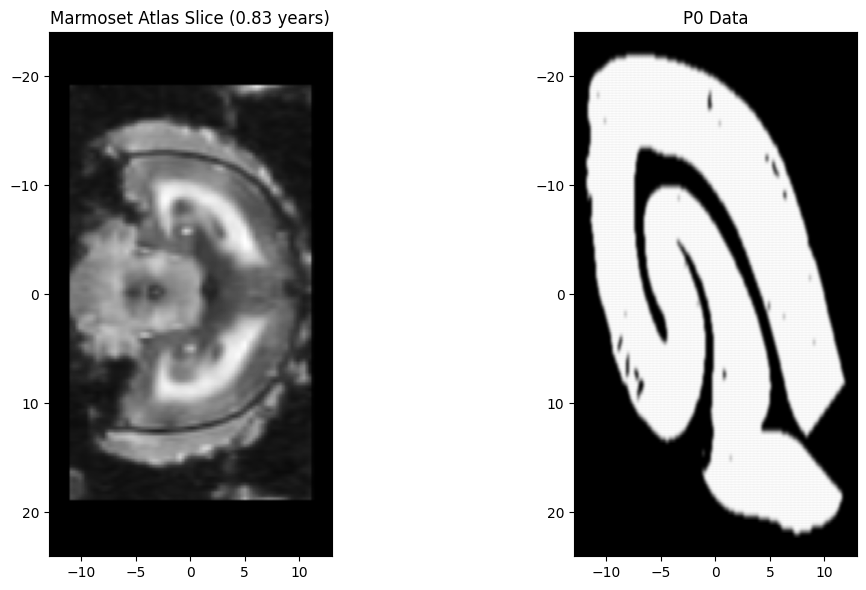

Atlas shape: (178, 178, 96)
Current slice: 70
Voxel sizes: (0.27, 0.27, 0.27)


In [104]:
#hard to fins a sutable slice... what i can see in the atlas, i do not see here well. Should try with more suitable age, like 7M, not P0.
# Get voxel sizes from the NIfTI header
voxel_sizes = img.header.get_zooms()  # Returns (x, y, z) voxel sizes in mm
dxA = np.array([voxel_sizes[0], voxel_sizes[1], voxel_sizes[2]])

# Get the dimensions of the atlas
nxA = imagefile.shape  # Should be (x, y, z) or (z, y, x)

# Create coordinate arrays for the atlas
xA = [np.arange(n)*d - (n-1)*d/2.0 for n,d in zip(nxA, dxA)]
XA = np.meshgrid(*xA, indexing='ij')

# Find the slice - you'll need to experiment with this
# For marmoset, slice numbers will be different from mouse
# Start with a middle slice and adjust
slice_ = 70#nxA[1] // 2  # Start with the middle slice in the z-dimension

# Create the side-by-side visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Display the atlas slice
# Note: You may need to adjust the indexing order
# Try different combinations if the image looks wrong:
# imagefile[slice, :, :] - if z is first dimension
# imagefile[:, slice, :] - if y is second dimension  
# imagefile[:, :, slice] - if z is third dimension
extentA = STalign.extent_from_x([xA[0], xA[2]])  # x and z coordinates
ax[0].imshow(imagefile[:, slice_, :], extent=extentA, cmap='gray')
ax[0].set_title('Marmoset Atlas Slice (0.83 years)')

# Display your target image (W from your rasterized data)
W_new = W[0, :, :]
ax[1].imshow(W_new, extent=extentA, cmap='gray')
ax[1].set_title('P0 Data')

plt.tight_layout()
plt.show()

# Print the slice number and shape for reference
print(f"Atlas shape: {imagefile.shape}")
print(f"Current slice: {slice_}")
print(f"Voxel sizes: {voxel_sizes}")

In [110]:
[x[0] for x in xI]

[-23.89500094950199, -23.89500094950199, -12.825000509619713]

In [109]:
xA[0]

array([-23.89500095, -23.62500094, -23.35500093, -23.08500092,
       -22.81500091, -22.5450009 , -22.27500089, -22.00500087,
       -21.73500086, -21.46500085, -21.19500084, -20.92500083,
       -20.65500082, -20.38500081, -20.1150008 , -19.84500079,
       -19.57500078, -19.30500077, -19.03500076, -18.76500075,
       -18.49500073, -18.22500072, -17.95500071, -17.6850007 ,
       -17.41500069, -17.14500068, -16.87500067, -16.60500066,
       -16.33500065, -16.06500064, -15.79500063, -15.52500062,
       -15.25500061, -14.9850006 , -14.71500058, -14.44500057,
       -14.17500056, -13.90500055, -13.63500054, -13.36500053,
       -13.09500052, -12.82500051, -12.5550005 , -12.28500049,
       -12.01500048, -11.74500047, -11.47500046, -11.20500045,
       -10.93500043, -10.66500042, -10.39500041, -10.1250004 ,
        -9.85500039,  -9.58500038,  -9.31500037,  -9.04500036,
        -8.77500035,  -8.50500034,  -8.23500033,  -7.96500032,
        -7.69500031,  -7.4250003 ,  -7.15500028,  -6.88

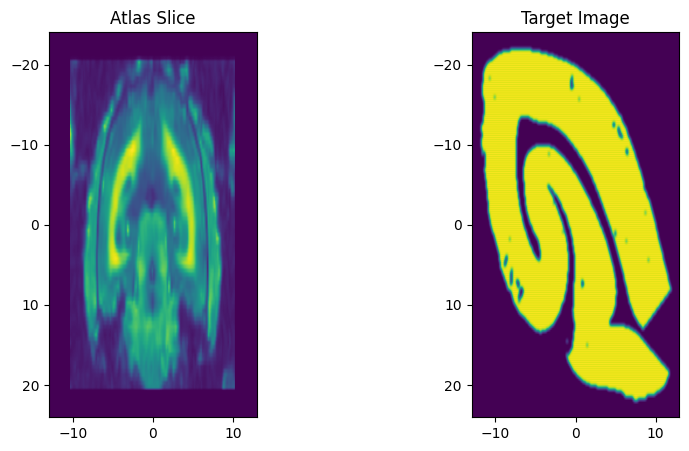

In [92]:
#define rotation angle
theta_deg = 90

fig,ax = plt.subplots(1,2, figsize=(10,5))
extentA = STalign.extent_from_x(xA[1:])
ax[0].imshow(rotate(imagefile[:, slice_, :], angle=theta_deg), extent=extentA)
ax[0].set_title('Atlas Slice')

ax[1].imshow(W_new, extent=extentA)
ax[1].set_title('Target Image')
fig.canvas.draw()


In [93]:
#define parameters for the alignment
sigmaA = 0.1 #standard deviation of artifact intensities
sigmaB = 0.1 #standard deviation of background intensities
sigmaM = 0.1 #standard deviation of matching tissue intenities
muA = torch.tensor([0.7,0.7,0.7],device='cpu') #average of artifact intensities
muB = torch.tensor([0,0,0],device='cpu') #average of background intensities

In [ ]:
# optionally can also define point that are paired in the images. But MRI looks really strange to me.....

In [94]:
xJ = [Y_1,X_1]
J = W_new[None]/np.mean(np.abs(W_new))
xI = xA
I = imagefile[None] / np.mean(np.abs(imagefile),keepdims=True)
I = np.concatenate((I,(I-np.mean(I))**2))
Inorm = STalign.normalize(I, t_min=0, t_max=1)
Jnorm = STalign.normalize(J, t_min=0, t_max=1)

In [98]:
dJ = [x[1]-x[0] for x in xJ]

In [99]:
dJ

[50.0, 50.0]

In [100]:
# initialize variables
scale_x = 4 #default = 0.9
scale_y = 4 #default = 0.9
scale_z = 0.9 #default = 0.9
theta0 = (np.pi/180)*theta_deg

# get an initial guess
#if 'Ti' in locals():
#    T = np.array([-xI[0][slice],np.mean(xJ[0])-(Ti[0]*scale_y),np.mean(xJ[1])-(Ti[1]*scale_x)])
#else:
#    T = np.array([-xI[0][slice],np.mean(xJ[0]),np.mean(xJ[1])])
#T = np.array([-xI[0][slice],0,0])


scale_atlas = np.array([[scale_z,0,0],
                        [0,scale_x,0],
                        [0,0,scale_y]])
L = np.array([[1.0,0.0,0.0],
             [0.0,np.cos(theta0),-np.sin(theta0)],
              [0.0,np.sin(theta0),np.cos(theta0)]])
L = np.matmul(L,scale_atlas)#np.identity(3)

In [102]:
STalign.LDDMM_3D_to_slice

<function STalign.STalign.LDDMM_3D_to_slice(xI, I, xJ, J, pointsI=None, pointsJ=None, L=None, T=None, A=None, v=None, xv=None, a=500.0, p=2.0, expand=1.25, nt=3, niter=5000, diffeo_start=0, epL=1e-06, epT=10.0, epV=1000.0, sigmaM=1.0, sigmaB=2.0, sigmaA=5.0, sigmaR=100000000.0, sigmaP=20.0, device='cpu', dtype=torch.float64, muA=None, muB=None)>

In [103]:
#%%time
#needs fixing
#NOW ALIGN - returns mat = affine transform, v = velocity, xv = pixel locations of velocity points
transform = STalign.LDDMM_3D_to_slice(
    xI,Inorm,xJ,Jnorm,L=L,
    nt=4,niter=800,
    a=250,
    device='cpu',
    sigmaA = sigmaA, #standard deviation of artifact intensities
    sigmaB = sigmaB, #standard deviation of background intensities
    sigmaM = sigmaM, #standard deviation of matching tissue intenities
    muA = muA, #average of artifact intensities
    muB = muB #average of background intensities
)

IndexError: index 1 is out of bounds for dimension 0 with size 1